# Econ 390 - Problem Set 12 Answers
## by M McMain
This problem set will cover Difference in Differences and RegEx. Be sure to import any packages your code needs to run and make sure the code runs without any errors.

1. [1 Point] Write a RegEx to find all Social Security Numbers in a string (it should accommodate `XXX-XX-XXXX` and `XXXXXXXXX`)

In [1]:
import re
# 3 digits, optional dash, two digits, optional dash, four digits
re.findall("\d{3}-?\d{2}-?\d{4}", "let me 123-45-6789 is an option, 11-3456789 is not, 123456789 is, 1-23-12 is not 12345 is not")

['123-45-6789', '123456789']

2. [2 Points] Write a RegEx to find prices either in `$` or `€` with optional commas or periods separating thousands, millions, etc. and optional comma or period for **two digit** decimals

In [2]:
# Big capture group for everything starting with euro or dollar
# First inner capture group is not returned, "?:", and is 1 to 3 digits
# Then another inner group starting with an optional comma/period followed by 3 digits, showing up 0+ times
# Final inner group is a comma/peroid followed by two digits, and is optional
re.findall("([$€](?:\d{1,3})(?:[,.]?\d{3})*(?:[,.]\d{2})?)", "test $1 and $1.24 and $1000000, but not 10 or $1,00.00")

['$1', '$1.24', '$100000', '$1,00']

3. Run the code block below to generate a dataset of 100 "Firms" sales numbers across six years. Assume starting in year 4 a policy went into effect that only effected `firm_type == 1` and we're trying to evaluate the effect of the policy. It's ambiguous as to whether it will improve sales or make them worse.

In [19]:
# Import the random package as we will be randomizing firm sales
import random
import pandas as pd
import matplotlib.pyplot as plt
# Set the seed for reproducability
random.seed(a=390)

# Initialize number of firms, periods, and firm_types
nfirms = 100
nperiods = 6
firm_types = 2

# Create lists for our variables of the appropriate size
firm = [0]*nfirms*nperiods
period = [0]*nfirms*nperiods
after = [0]*nfirms*nperiods
firm_type = [0]*nfirms*nperiods
sales = [0]*nfirms*nperiods
sales_change = [0]*nfirms*nperiods
sales_slope = [0]*firm_types
sales_slope_new = [0]*firm_types

# Generate a random sales slope for each firm type before and after
for i in range(firm_types):
    sales_slope[i] = random.uniform(0.5,1.5)
    sales_slope_new[i] = random.uniform(0.5,1.5)
# Set the new sales slope for firm_type == 0 equal to the old one since they're untreated
sales_slope_new[0] = sales_slope[0]

# Fill out the lists by looping through the firms and periods
index = 0
for i in range(nfirms):
    for j in range(nperiods):
        firm[index] = i
        period[index] = j
        firm_type[index] = i % 2
        # If we're in the before periods, use the old slope
        if j < 3:
            sales[index] = (j+1)*sales_slope[i % 2] + random.gauss(mu=0,sigma=0.05)
            after[index] = 0
        # In the after periods, use the new slope
        else:
            sales[index] = (j+1)*sales_slope_new[i % 2] + random.gauss(mu=0,sigma=0.05)
            after[index] = 1

        # If we are not in period zero, calculate the sales_change
        if j != 0:
            sales_change[index] = sales[index] - sales[index-1]
        else:
            sales_change[index] = None

        index += 1

# Convert to a dataframe
df = pd.DataFrame({"firm":firm,"period":period,"after":after,"firm_type":firm_type,"sales":sales,"sales_change":sales_change})

- [2 Point] Create a scatterplot with matplotlib of sales over time, with the dots being colored by their firm type and a vertical line at 2.5
  - *Hint: To do so with matplotlib alone, create a scatter of just `firm_type == 0` with one color, then add another scatter of `firm_type == 1` with a different color*
  - In the cell below do the same thing but with `sales_change` instead of sales
  - Reflect on how these two compare and if this looks like a good Diff-in-Diff

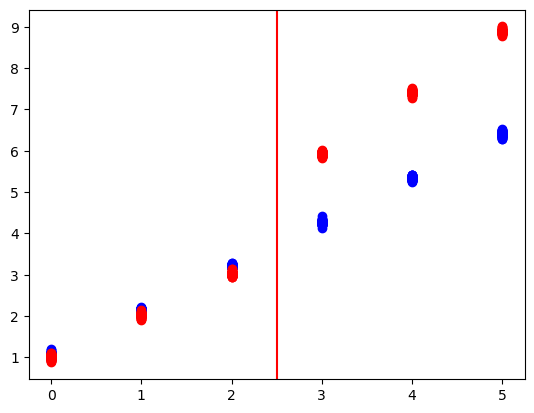

In [20]:
# Initialize the plot
fig, ax = plt.subplots()
# Plot scatterplot of the untreated
ax.scatter(df[df["firm_type"]==0]["period"],df[df["firm_type"]==0]["sales"],color="blue")
# Plot scatterplot of treated
ax.scatter(df[df["firm_type"]==1]["period"],df[df["firm_type"]==1]["sales"],color="red")
# Vertical line at 2.5 which is when treatment occurs
ax.axvline(x=2.5, color="red")
plt.show()

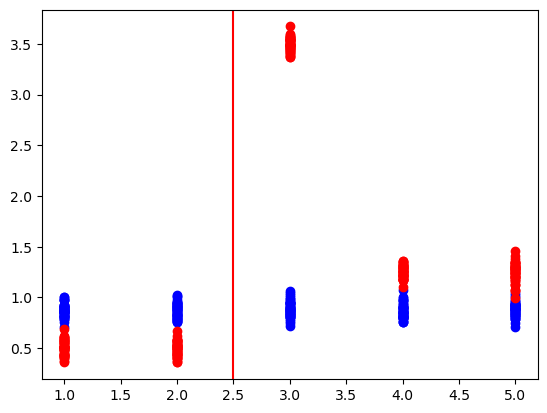

In [18]:
fig, ax = plt.subplots()
# Plot scatterplot of the untreated
ax.scatter(df[df["firm_type"]==0]["period"],df[df["firm_type"]==0]["sales_change"],color="blue")
# Plot scatterplot of treated
ax.scatter(df[df["firm_type"]==1]["period"],df[df["firm_type"]==1]["sales_change"],color="red")
# Vertical line at 2.5 which is when treatment occurs
ax.axvline(x=2.5, color="red")
plt.show()

- [2 Points] Using `statsmodels.formula.api`, run a Difference in Differences regression, call it `model1`, on the slope of sales across firm type and after
  - *Hint 1: The first regression equation is $sales_{i,t} = \alpha + \beta_1 firm\_type_i + \beta_2 after_t + \beta_3 firm\_type_i \times after_t + \beta_4 period_t + \beta_5 firm\_type_i \times period_t + \beta_6 after_t \times period_t +\beta_7 firm\_type_{i} \times after_t \times period_t + \epsilon_{i,t}$ where $i$ is firm and $t$ is time period*
  - *Hint 2: There is a simple way to include all of these individual regressors in the `smf.ols` function*
  - Use heteroskedastic standard errors
  - Print a summary of the results
  - Reflect on the results

In [6]:
import statsmodels.formula.api as smf 
# Create model above, which is all permutations of treatment status, before/afterm and period
model1 = smf.ols("sales ~ firm_type*after*period",data=df).fit(cov_type="HC1")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.170e+05
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        07:58:02   Log-Likelihood:                 975.15
No. Observations:                 600   AIC:                            -1934.
Df Residuals:                     592   BIC:                            -1899.
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1

- [1 Point] Run another regression, call it `model2`, this time of the change in sales on firm type interacted with after
    - Notice that there is an impact effect of the policy on the change in sales.
    - To account for this, create an indicator variable for being in the first policy year (i.e. `period == 3`) and include that interacted with firm type in the regression
    - *Hint: This regression equation is $sales\_change_{i,t} = \alpha + \beta_1 firm\_type_i + \beta_2 after + \beta_3 firm\_type_i \times after_t + \beta_4 firm\_type_i \times year\_three_t$*

In [7]:
df["year_three"] = df["period"] == 3
# Similar to above but with change in sales and looking specifically in year three
model2 = smf.ols("sales_change ~ firm_type*after + year_three*firm_type",data=df).fit(cov_type="HC1")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           sales_change   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     5367.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        07:58:02   Log-Likelihood:                 636.95
No. Observations:                 500   AIC:                            -1262.
Df Residuals:                     494   BIC:                            -1237.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

- [1 Point] Using only the regression results, what is the estimated effect of the policy? Does it matter whether we run the regression on the sales vs. the change in sales? *Hint: What is $\beta_7$ in `model1` and $\beta_3$ in `model2`?*

The effect of the policy was increasing sales by an additional 0.4782 every period.

- [1 Point]  What is the actual effect? *Hint: What is `sales_slope_new - sales_slope` for `firm_type == 1`*
    - Is the real value within the 95% confidence interval for the estimated effect above?

In [8]:
# Compare true sales slops
sales_slope_new[1] - sales_slope[1]

0.4731221688559959

Yes, 0.473 is between 0.459 and 0.497 for `model1` and 0.452 and 0.505 for `model2`